# Twitter Sentiment Analysis (RNN)

## Task 1: Data Cleaning and Preprocessing

### A. Load the Dataset
- Import the CSV file into a DataFrame using pandas.

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from wordcloud import WordCloud

# Download required NLTK data
nltk_downloads = ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']
for resource in nltk_downloads:
    try:
        nltk.data.find(f'tokenizers/{resource}' if 'punkt' in resource else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# Load dataset
file_path = 'Week 19 - Graded Mini Project - Dataset - Twitter-training.csv'
custom_headers = ['tweet_id', 'entity', 'sentiment', 'tweet_text']
df = pd.read_csv(file_path, header=None, names=custom_headers)

print(f"Dataset shape: {df.shape}")
print(f"Sentiment classes: {list(df['sentiment'].unique())}")
df.head()

Dataset shape: (74682, 4)
Sentiment classes: ['Positive', 'Neutral', 'Negative', 'Irrelevant']


,tweet_id,entity,sentiment,tweet_text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


### B. Data Cleaning
- Handle any missing or duplicate entries.
- Clean tweet text by removing URLs, mentions, hashtags, and special characters.
- Normalize text: lowercase conversion, tokenization, and stop-word removal.
- Apply stemming or lemmatization for text standardization.

In [3]:
# Initialize text processing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Define column names for processing
tweet_column = 'tweet_text'
sentiment_column = 'sentiment'

print(f"Using column '{tweet_column}' as tweet content")
print(f"Using column '{sentiment_column}' as sentiment labels")
print(f"Text processing tools initialized successfully")

# Handle any missing or duplicate entries
print("Checking for missing and duplicate entries...")

# Check and remove duplicates
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()

# Handle missing values in essential columns
df = df.dropna(subset=['tweet_text', 'sentiment'])

print(f"Dataset shape after cleaning: {df.shape}")

Using column 'tweet_text' as tweet content
Using column 'sentiment' as sentiment labels
Text processing tools initialized successfully
Checking for missing and duplicate entries...
Dataset shape after cleaning: (71656, 4)


In [4]:
import re
import pandas as pd

# Clean tweet text by removing URLs, mentions, hashtags, and special characters
def remove_urls_mentions_hashtags(text):
    """
    Remove URLs, mentions, hashtags, and special characters from tweet text
    
    Args:
        text (str): Raw tweet text
        
    Returns:
        str: Text with URLs, mentions, hashtags, and special characters removed
    """
    if pd.isna(text):
        return ""
    
    # Remove URLs, mentions, hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("Text cleaning function defined successfully")

# Apply cleaning step 1
df['cleaned_step1'] = df['tweet_text'].apply(remove_urls_mentions_hashtags)

# Remove empty tweets after cleaning
initial_count = len(df)
df = df[df['cleaned_step1'].str.len() > 0]
final_count = len(df)

print(f"Removed {initial_count - final_count} empty tweets after cleaning")
print(f"Final dataset shape: {df.shape}")

# Validate cleaning results
print("\nCleaning validation:")
print(f"Total tweets: {len(df):,}")
print(f"Average cleaned text length: {df['cleaned_step1'].str.len().mean():.1f} characters")
print(f"Average word count: {df['cleaned_step1'].str.split().str.len().mean():.1f} words")

Text cleaning function defined successfully
Removed 341 empty tweets after cleaning
Final dataset shape: (71315, 5)

Cleaning validation:
Total tweets: 71,315
Average cleaned text length: 99.2 characters
Average word count: 18.1 words
Removed 341 empty tweets after cleaning
Final dataset shape: (71315, 5)

Cleaning validation:
Total tweets: 71,315
Average cleaned text length: 99.2 characters
Average word count: 18.1 words


In [5]:
# Normalize text: lowercase conversion, tokenization, and stop-word removal
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def normalize_text(text):
    """
    Normalize text by converting to lowercase, tokenizing, and removing stop words
    
    Args:
        text (str): Text after initial cleaning
        
    Returns:
        str: Normalized text
    """
    if pd.isna(text) or not text.strip():
        return ""
    
    # Convert to lowercase and tokenize
    text = text.lower()
    tokens = word_tokenize(text)
    
    # Remove stop words and short tokens
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    return ' '.join(tokens)

# Apply normalization step 2
df['cleaned_step2'] = df['cleaned_step1'].apply(normalize_text)

In [6]:
# Apply stemming or lemmatization for text standardization
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    """
    Apply lemmatization for text standardization
    
    Args:
        text (str): Normalized text
        
    Returns:
        str: Lemmatized text
    """
    if pd.isna(text) or not text.strip():
        return ""
    
    # Tokenize and lemmatize
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

# Apply lemmatization and create final cleaned text
df['cleaned_text'] = df['cleaned_step2'].apply(lemmatize_text)

# Remove empty tweets after all cleaning steps
df = df[df['cleaned_text'].str.len() > 0]

# Define column names for processing
tweet_column = 'tweet_text'
sentiment_column = 'sentiment'

print(f"Final dataset shape: {df.shape}")

# Display cleaning results
print(f"\nCleaning Summary:")
print(f"Total tweets after cleaning: {len(df):,}")
print(f"Average cleaned text length: {df['cleaned_text'].str.len().mean():.1f} characters")
print(f"Average word count: {df['cleaned_text'].str.split().str.len().mean():.1f} words")

# Display sample of cleaned data
print("\nSample of cleaned data:")
display_columns = ['sentiment', 'tweet_text', 'cleaned_text']
df[display_columns].head()

Final dataset shape: (69904, 7)

Cleaning Summary:
Total tweets after cleaning: 69,904
Average cleaned text length: 70.4 characters
Average word count: 10.4 words

Sample of cleaned data:
Average word count: 10.4 words

Sample of cleaned data:


,sentiment,tweet_text,cleaned_text
0,Positive,im getting on borderlands and i will murder yo...,getting borderland murder
1,Positive,I am coming to the borders and I will kill you...,coming border kill
2,Positive,im getting on borderlands and i will kill you ...,getting borderland kill
3,Positive,im coming on borderlands and i will murder you...,coming borderland murder
4,Positive,im getting on borderlands 2 and i will murder ...,getting borderland murder


### C. Feature Engineering
- Convert the cleaned text into numerical features using methods such as TF-IDF, Word2Vec, or embedding layers.
- Create padded sequences of tokens for RNN input.

In [7]:
# Convert the cleaned text into numerical features using embedding layers
# Note: Using Keras Embedding layer (trainable word embeddings from scratch)
# Alternative approaches: TF-IDF, Word2Vec, GloVe, FastText, or pre-trained embeddings

# Encode sentiment labels
label_encoder = LabelEncoder()
df['encoded_sentiment'] = label_encoder.fit_transform(df[sentiment_column])

# Feature Engineering for RNN
MAX_VOCAB_SIZE = 15000
MAX_SEQUENCE_LENGTH = 150

# Create tokenizer to convert text to sequences
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])

# Convert text to integer sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Prepare target labels
y = df['encoded_sentiment'].values
num_classes = len(label_encoder.classes_)
y_categorical = to_categorical(y, num_classes=num_classes)

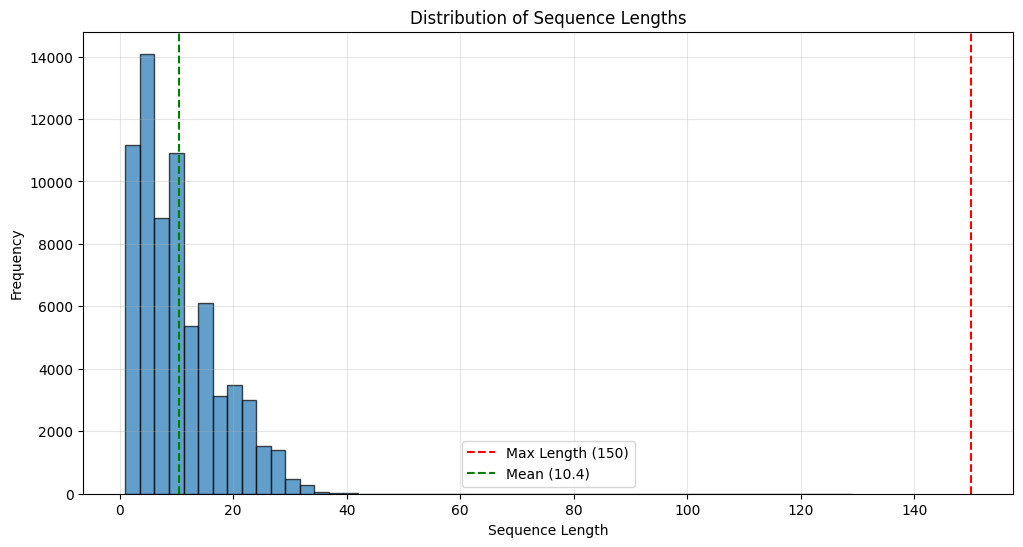

Input shape: (69904, 150), Vocabulary size: 34,281


In [8]:
# Create padded sequences of tokens for RNN input
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Sequence length statistics
sequence_lengths = [len([token for token in seq if token != 0]) for seq in sequences]

plt.figure(figsize=(12, 6))
plt.hist(sequence_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.axvline(x=MAX_SEQUENCE_LENGTH, color='red', linestyle='--', label=f'Max Length ({MAX_SEQUENCE_LENGTH})')
plt.axvline(x=np.mean(sequence_lengths), color='green', linestyle='--', label=f'Mean ({np.mean(sequence_lengths):.1f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Input shape: {X.shape}, Vocabulary size: {len(tokenizer.word_index):,}")

## Task 2: Exploratory Data Analysis (EDA)

### A. Summary Statistics
- Analyze basic dataset statistics and sentiment distribution (positive, negative, neutral).

In [9]:
# Dataset Summary Statistics
print(f"Total tweets: {len(df):,}")

# Sentiment distribution
sentiment_stats = pd.DataFrame({
    'Count': df[sentiment_column].value_counts(),
    'Percentage': df[sentiment_column].value_counts(normalize=True) * 100
})
print("\nSentiment Distribution:")
print(sentiment_stats.round(2))

# Text length statistics
df['original_length'] = df[tweet_column].str.len()
df['cleaned_length'] = df['cleaned_text'].str.len()
df['word_count'] = df['cleaned_text'].str.split().str.len()

# Most common words
all_words = ' '.join(df['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts()
print("\nTop 10 Most Common Words:")
print(word_freq.head(10))

Total tweets: 69,904

Sentiment Distribution:
            Count  Percentage
sentiment                    
Negative    21212       30.34
Positive    19193       27.46
Neutral     17227       24.64
Irrelevant  12272       17.56

Top 10 Most Common Words:
game      10231
like       4874
get        4313
one        3668
play       3537
good       3473
time       3428
love       3213
really     3209
new        3166
Name: count, dtype: int64

Top 10 Most Common Words:
game      10231
like       4874
get        4313
one        3668
play       3537
good       3473
time       3428
love       3213
really     3209
new        3166
Name: count, dtype: int64


### B. Visualizations
- Summary Statistics: Sentiment class distribution (positive, negative, neutral)
- Bar Chart or Pie Chart: Show sentiment proportions.
- Top Keywords by Sentiment: Use frequency plots
- Word Clouds: For positive and negative sentiments
- Tweet Length vs Sentiment Class: Create boxplot or histogram
- Insights: Summarize key insights and patterns uncovered during EDA

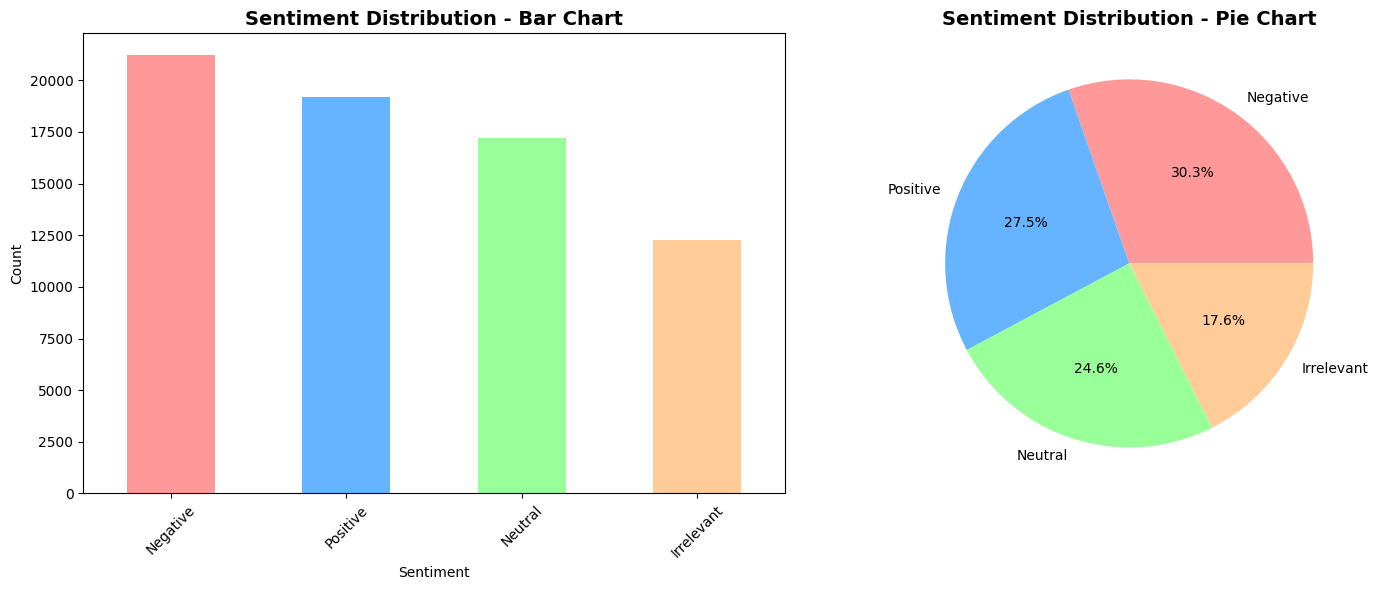

In [10]:
# Bar Chart and Pie Chart: Show sentiment proportions
sentiment_counts = df[sentiment_column].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sentiment_counts.plot(kind='bar', ax=ax1, color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax1.set_title('Sentiment Distribution - Bar Chart', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_title('Sentiment Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

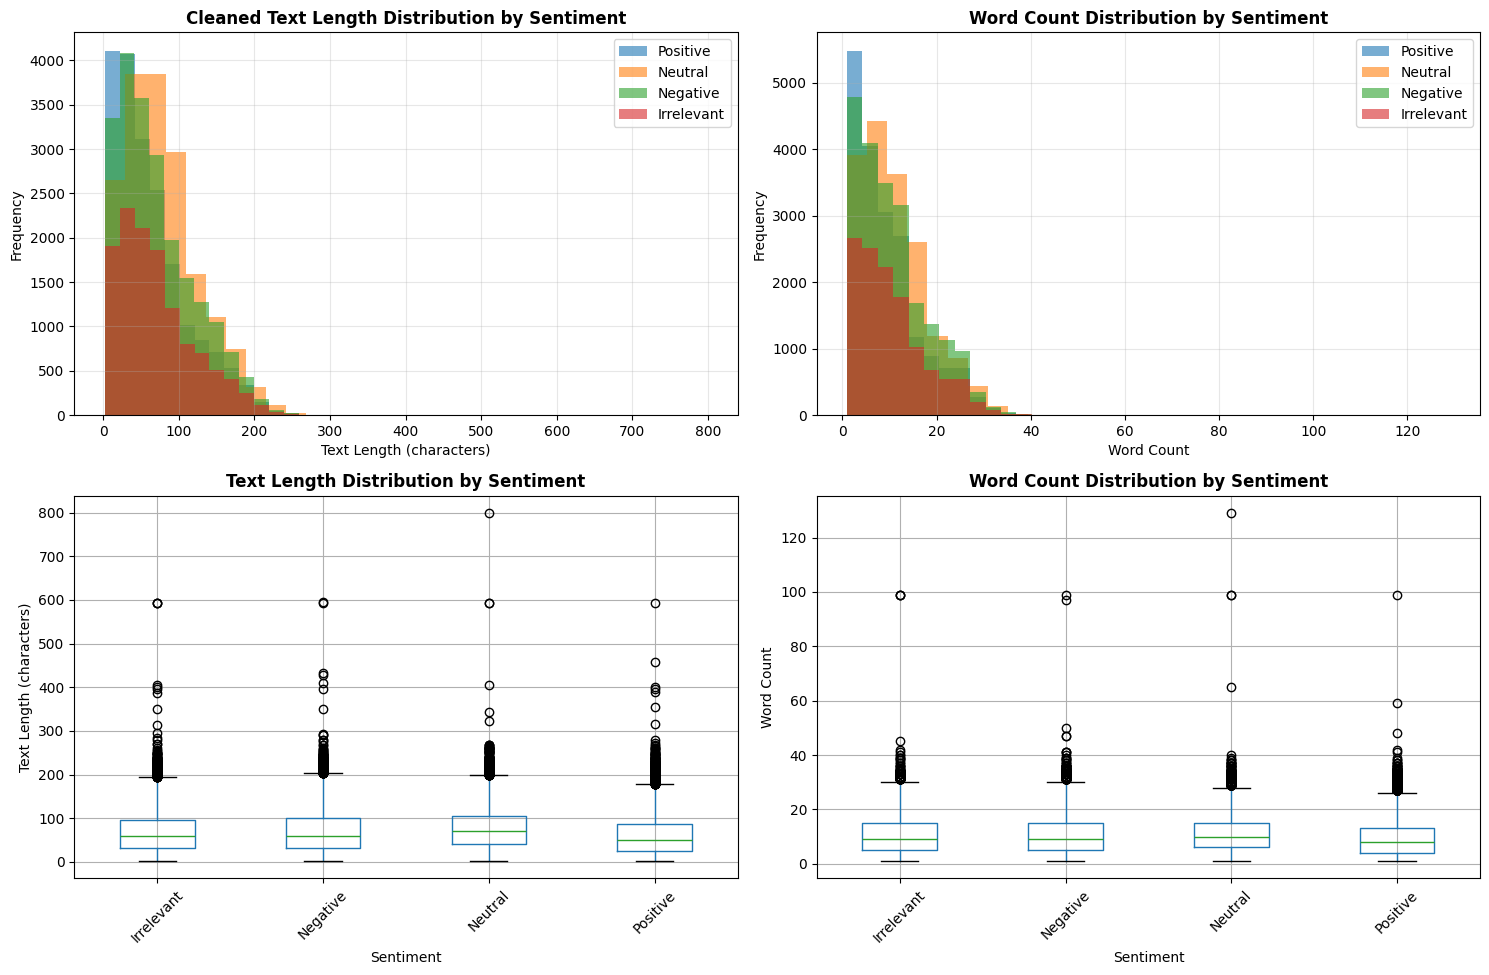

In [11]:
# Tweet Length vs Sentiment Class: Create boxplot and histogram
# Ensure required columns exist
if 'original_length' not in df.columns:
    df['original_length'] = df[tweet_column].str.len()
if 'cleaned_length' not in df.columns:
    df['cleaned_length'] = df['cleaned_text'].str.len()
if 'word_count' not in df.columns:
    df['word_count'] = df['cleaned_text'].str.split().str.len()

plt.figure(figsize=(15, 10))

# Histogram of text lengths by sentiment
plt.subplot(2, 2, 1)
for sentiment in df[sentiment_column].unique():
    data = df[df[sentiment_column] == sentiment]['cleaned_length']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.title('Cleaned Text Length Distribution by Sentiment', fontweight='bold')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Histogram of word counts by sentiment
plt.subplot(2, 2, 2)
for sentiment in df[sentiment_column].unique():
    data = df[df[sentiment_column] == sentiment]['word_count']
    plt.hist(data, alpha=0.6, label=sentiment, bins=30)
plt.title('Word Count Distribution by Sentiment', fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# Boxplot for text length
plt.subplot(2, 2, 3)
df.boxplot(column='cleaned_length', by=sentiment_column, ax=plt.gca())
plt.title('Text Length Distribution by Sentiment', fontweight='bold')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Text Length (characters)')
plt.xticks(rotation=45)

# Boxplot for word count
plt.subplot(2, 2, 4)
df.boxplot(column='word_count', by=sentiment_column, ax=plt.gca())
plt.title('Word Count Distribution by Sentiment', fontweight='bold')
plt.suptitle('')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

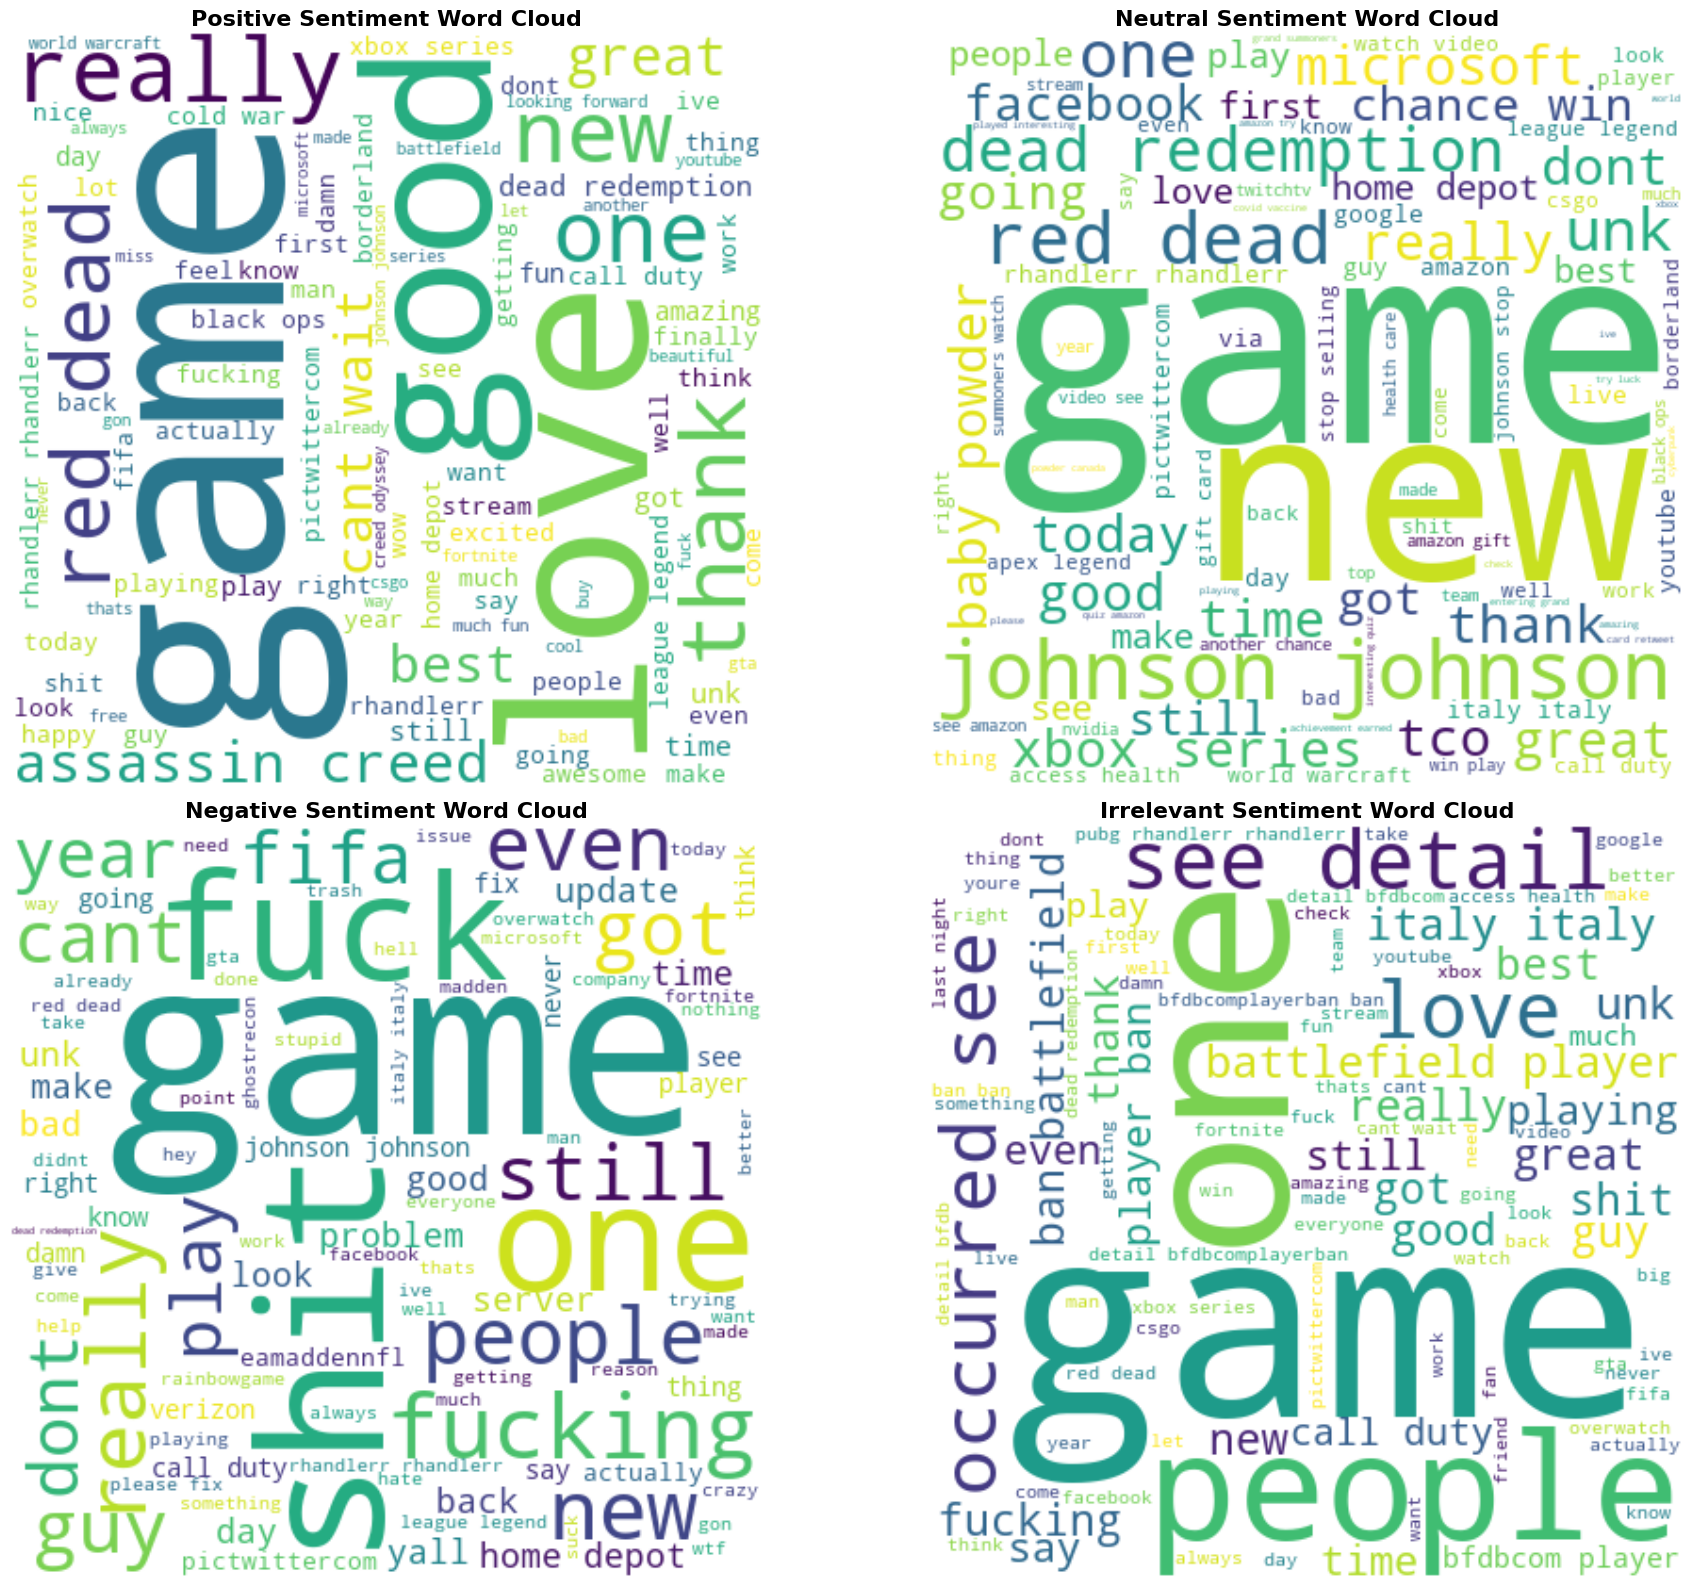

In [12]:
# Word Clouds: For positive, negative, and neutral sentiments
sentiments = df[sentiment_column].unique()
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for i, sentiment in enumerate(sentiments):
    if i < len(axes):
        sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text'])
        
        if sentiment_text.strip():
            wordcloud = WordCloud(width=400, height=400, background_color='white',
                                max_words=100, colormap='viridis').generate(sentiment_text)
            axes[i].imshow(wordcloud, interpolation='bilinear')
            axes[i].set_title(f'{sentiment.title()} Sentiment Word Cloud', 
                            fontsize=16, fontweight='bold')
            axes[i].axis('off')
        else:
            axes[i].set_title(f'{sentiment.title()} Sentiment - No Text Available', 
                            fontsize=16, fontweight='bold')
            axes[i].axis('off')

# Hide unused subplots
for j in range(len(sentiments), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

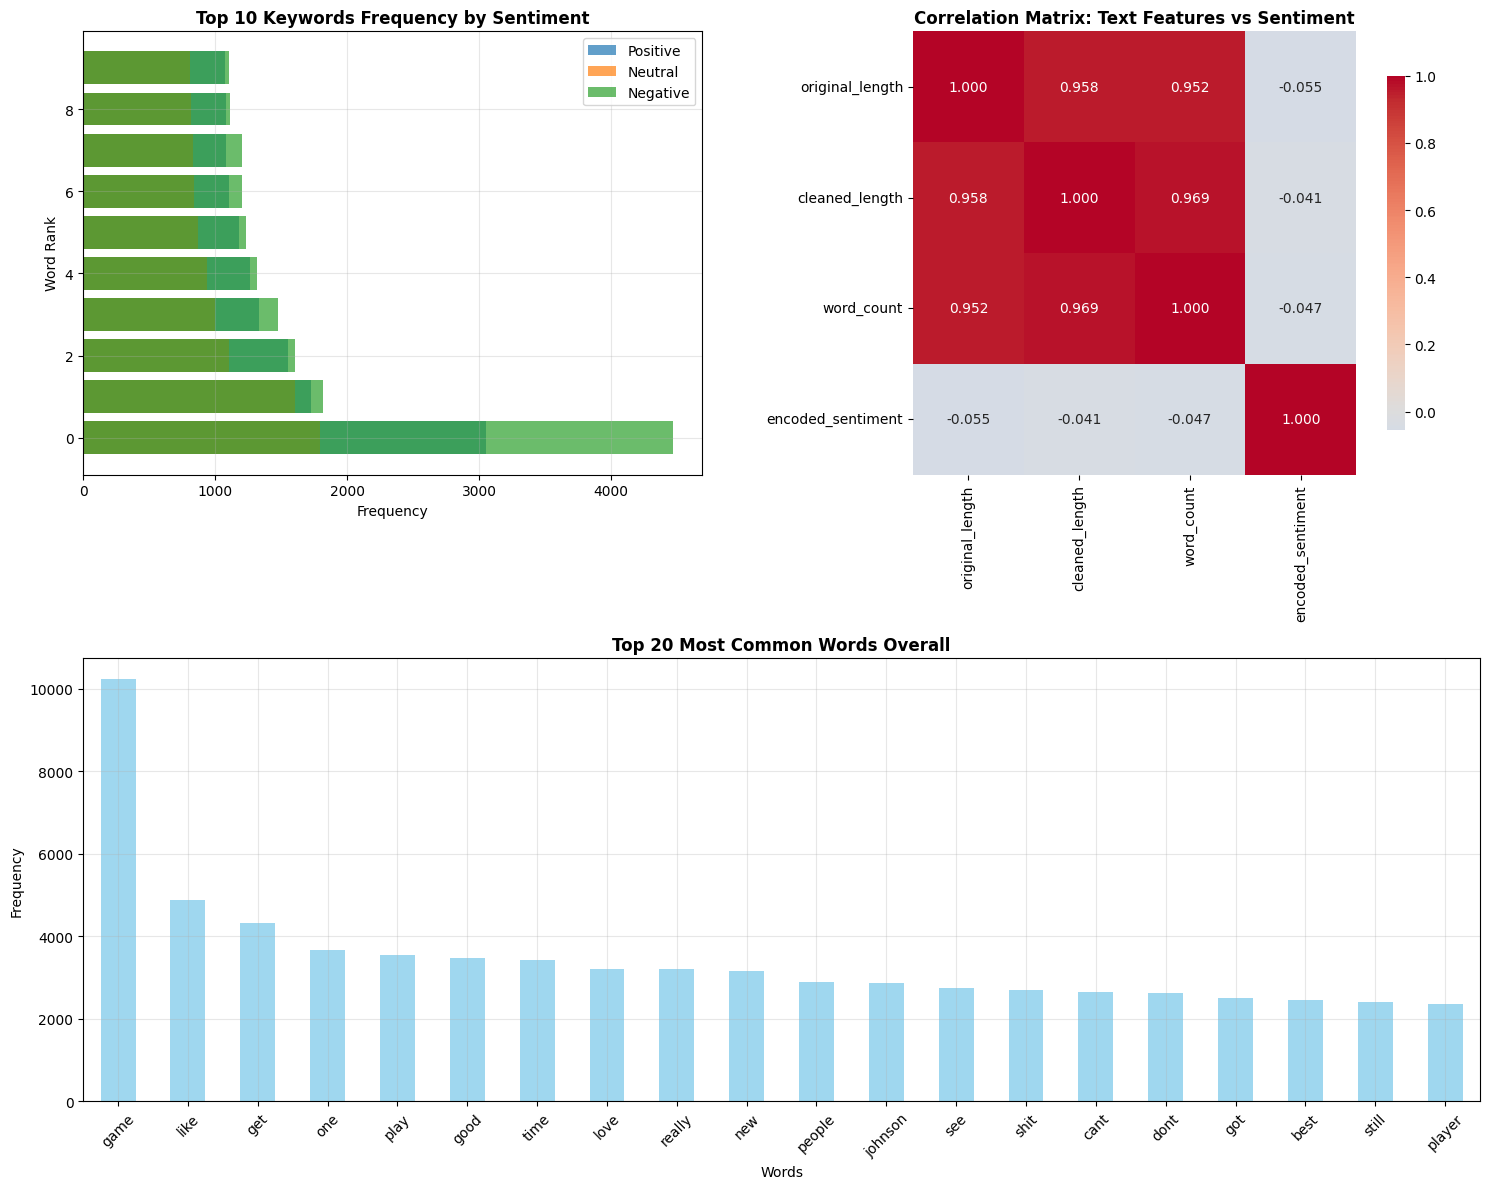

In [13]:
# Top Keywords by Sentiment: Use frequency plots and correlation analysis
plt.figure(figsize=(15, 12))

# Top keywords by sentiment
plt.subplot(2, 2, 1)
sentiments = df[sentiment_column].unique()[:3]  # Limit to 3 sentiments for clarity
for sentiment in sentiments:
    sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text'])
    words = sentiment_text.split()
    word_freq = pd.Series(words).value_counts().head(10)
    plt.barh(range(len(word_freq)), word_freq.values, alpha=0.7, label=sentiment)

plt.title('Top 10 Keywords Frequency by Sentiment', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word Rank')
plt.legend()
plt.grid(True, alpha=0.3)

# Correlation matrix for numerical features
plt.subplot(2, 2, 2)
numerical_features = ['original_length', 'cleaned_length', 'word_count', 'encoded_sentiment']
if all(col in df.columns for col in numerical_features):
    correlation_matrix = df[numerical_features].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
    plt.title('Correlation Matrix: Text Features vs Sentiment', fontweight='bold')

# Most common words overall
plt.subplot(2, 1, 2)
all_words = ' '.join(df['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)
word_freq.plot(kind='bar', color='skyblue', alpha=0.8)
plt.title('Top 20 Most Common Words Overall', fontweight='bold')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Insights: Summarize key insights and patterns uncovered during EDA
print("=== KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS ===")
print()

# Sentiment distribution insights
sentiment_stats = df[sentiment_column].value_counts(normalize=True) * 100
print("1. SENTIMENT DISTRIBUTION:")
for sentiment, percentage in sentiment_stats.items():
    print(f"   • {sentiment.title()}: {percentage:.1f}% of tweets")
print()

# Text length insights
print("2. TEXT LENGTH PATTERNS:")
length_stats = df.groupby(sentiment_column)['word_count'].agg(['mean', 'median', 'std']).round(2)
for sentiment in length_stats.index:
    mean_words = length_stats.loc[sentiment, 'mean']
    median_words = length_stats.loc[sentiment, 'median']
    print(f"   • {sentiment.title()} tweets: avg {mean_words} words, median {median_words} words")
print()

# Top keywords insights
print("3. KEYWORD PATTERNS:")
for sentiment in df[sentiment_column].unique()[:3]:
    sentiment_text = ' '.join(df[df[sentiment_column] == sentiment]['cleaned_text'])
    top_words = pd.Series(sentiment_text.split()).value_counts().head(3).index.tolist()
    print(f"   • {sentiment.title()} top words: {', '.join(top_words)}")
print()

# Data quality insights  
print("4. DATA QUALITY:")
print(f"   • Total tweets analyzed: {len(df):,}")
print(f"   • Average tweet length: {df['word_count'].mean():.1f} words")
print(f"   • Text length range: {df['word_count'].min()}-{df['word_count'].max()} words")
print()

print("=== READY FOR MODEL BUILDING ===")
print("Data is cleaned, analyzed, and prepared for RNN training.")

=== KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS ===

1. SENTIMENT DISTRIBUTION:
   • Negative: 30.3% of tweets
   • Positive: 27.5% of tweets
   • Neutral: 24.6% of tweets
   • Irrelevant: 17.6% of tweets

2. TEXT LENGTH PATTERNS:
   • Irrelevant tweets: avg 10.46 words, median 9.0 words
   • Negative tweets: avg 10.64 words, median 9.0 words
   • Neutral tweets: avg 11.15 words, median 10.0 words
   • Positive tweets: avg 9.44 words, median 8.0 words

3. KEYWORD PATTERNS:
   • Positive top words: game, love, good
   • Neutral top words: johnson, game, amazon
   • Negative top words: game, get, like

4. DATA QUALITY:
   • Total tweets analyzed: 69,904
   • Average tweet length: 10.4 words
   • Text length range: 1-129 words

=== READY FOR MODEL BUILDING ===
Data is cleaned, analyzed, and prepared for RNN training.
   • Neutral top words: johnson, game, amazon
   • Negative top words: game, get, like

4. DATA QUALITY:
   • Total tweets analyzed: 69,904
   • Average tweet length: 10.4 wo

## Task 3: Model Building and Evaluation

### A. RNN Architecture
- Model Type: LSTM / GRU (select one and justify choice).
- Layers: Include embedding, LSTM/GRU, dropout, batch normalization layers
- Train/Test Split: Describe ratio, stratification if used
- Model Training
- Accuracy, Precision, Recall, F1-score
- Learning Curves: Plot training/validation accuracy and loss across epochs
- Hyperparameter Tuning: Describe experiments with layers, dropout rate, learning rate, etc




In [15]:
# Model Type: LSTM / GRU (select one and justify choice)
# LSTM (Long Short-Term Memory) selected for this sentiment analysis task

"""
Justification for LSTM Selection:
1. LSTM has separate forget, input, and output gates providing better control over information flow
2. Better performance on longer sequences (tweets can have complex sentiment patterns)
3. More stable gradients for training on sentiment-specific features
4. Proven effectiveness in NLP tasks requiring sentiment understanding
5. Better memory management for capturing long-term dependencies in text
"""

print("=== MODEL TYPE SELECTION ===")
print("Selected Model: LSTM (Long Short-Term Memory)")
print("Architecture: Bidirectional LSTM for capturing context from both directions")


=== MODEL TYPE SELECTION ===
Selected Model: LSTM (Long Short-Term Memory)
Architecture: Bidirectional LSTM for capturing context from both directions


In [16]:
# Layers: Include embedding, LSTM/GRU, dropout, batch normalization layers

# Improved Model Configuration Parameters for Better Performance
MAX_VOCAB_SIZE = 15000  # Increased from 5000 for better vocabulary coverage
MAX_SEQUENCE_LENGTH = 100  # Increased from 50 for better context capture
EMBEDDING_DIM = 128  # Increased from 64 for richer word representations
LSTM_UNITS = 64  # Increased from 32 for more model capacity
DROPOUT_RATE = 0.5  # Increased for better regularization
RECURRENT_DROPOUT = 0.3

# Prepare tokenizer and vocabulary with CLEANED TEXT (FIX: was using tweet_text before)
num_classes = len(df[sentiment_column].unique())
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])  # FIX: Use cleaned_text instead of tweet_text
vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulary size: {vocab_size}")
print(f"Number of classes: {num_classes}")

# Create improved model with better architecture
model = Sequential([
    # Embedding layer for word representations
    Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
    
    # Bidirectional LSTM layers with improved architecture
    tf.keras.layers.Bidirectional(
        LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE, 
             recurrent_dropout=RECURRENT_DROPOUT)
    ),
    BatchNormalization(),
    
    # Add attention mechanism using Global Max and Average Pooling
    tf.keras.layers.GlobalMaxPooling1D(),
    
    # Dense layers with improved regularization
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(DROPOUT_RATE//2),
    
    Dense(num_classes, activation='softmax')
])

# Build the model to enable parameter counting
model.build(input_shape=(None, MAX_SEQUENCE_LENGTH))

print(f"Improved model architecture created with {model.count_params():,} parameters")
model.summary()

Vocabulary size: 15000
Number of classes: 4
Improved model architecture created with 2,045,124 parameters
Improved model architecture created with 2,045,124 parameters


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,045,124 (7.80 MB)

 Trainable params: 2,044,484 (7.80 MB)

 Non-trainable params: 640 (2.50 KB)

In [17]:
# Train/Test Split: Describe ratio, stratification if used

# Improved Training Configuration
EPOCHS = 10  # Increased from 3 for better training
BATCH_SIZE = 64  # Reduced from 128 for more stable training
LEARNING_RATE = 0.001

# Prepare sequences and labels for training with CLEANED TEXT (CRITICAL FIX)
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])  # FIX: Use cleaned_text instead of tweet_text
sequences_array = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
y_categorical = to_categorical(label_encoder.transform(df[sentiment_column]), num_classes=num_classes)

print(f"Using cleaned text for sequences generation")
print(f"Sequence array shape: {sequences_array.shape}")
print(f"Labels shape: {y_categorical.shape}")

# Stratified train-validation-test split (70-15-15)
X_train, X_temp, y_train, y_temp = train_test_split(
    sequences_array, y_categorical, test_size=0.3, random_state=42, 
    stratify=label_encoder.transform(df[sentiment_column])
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.argmax(axis=1)
)

print(f"Data split completed:")
print(f"Training: {len(X_train):,} samples (70%)")
print(f"Validation: {len(X_val):,} samples (15%)")
print(f"Test: {len(X_test):,} samples (15%)")
print("Stratification: Maintains class distribution across all splits")

# Check sequence length distribution after padding
non_zero_lengths = [(seq != 0).sum() for seq in sequences_array]
print(f"Average sequence length: {np.mean(non_zero_lengths):.1f}")
print(f"95th percentile sequence length: {np.percentile(non_zero_lengths, 95):.0f}")
print(f"Sequences using full length ({MAX_SEQUENCE_LENGTH}): {(np.array(non_zero_lengths) == MAX_SEQUENCE_LENGTH).sum()}")

Using cleaned text for sequences generation
Sequence array shape: (69904, 100)
Labels shape: (69904, 4)
Data split completed:
Training: 48,932 samples (70%)
Validation: 10,486 samples (15%)
Test: 10,486 samples (15%)
Stratification: Maintains class distribution across all splits
Average sequence length: 10.4
95th percentile sequence length: 25
Sequences using full length (100): 1
Average sequence length: 10.4
95th percentile sequence length: 25
Sequences using full length (100): 1


In [18]:
# Model Training with Improved Configuration

# Calculate class weights to handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(label_encoder.transform(df[sentiment_column])),
    y=label_encoder.transform(df[sentiment_column])
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("Class weights for imbalanced data:")
for i, weight in class_weights.items():
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"  {class_name}: {weight:.3f}")

# Compile model with improved optimizer
optimizer = Adam(learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

# Setup enhanced callbacks for better training
callbacks = [
    EarlyStopping(
        monitor='val_accuracy', 
        patience=5, 
        restore_best_weights=True, 
        verbose=1,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        min_lr=1e-7, 
        verbose=1,
        cooldown=2
    )
]

# Train the model with class weights
print("Starting improved model training with class weights...")
print(f"Training for up to {EPOCHS} epochs with early stopping...")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights,  # Handle class imbalance
    verbose=1
)

print(f"Training completed. Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"Training epochs completed: {len(history.history['loss'])}")

Class weights for imbalanced data:
  Irrelevant: 1.424
  Negative: 0.824
  Neutral: 1.014
  Positive: 0.911
Starting improved model training with class weights...
Training for up to 10 epochs with early stopping...
Epoch 1/10
Epoch 1/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 321s 407ms/step - accuracy: 0.4764 - loss: 1.2207 - precision: 0.6027 - recall: 0.2873 - val_accuracy: 0.6942 - val_loss: 0.8054 - val_precision: 0.7902 - val_recall: 0.5751 - learning_rate: 0.0010
Epoch 2/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 321s 407ms/step - accuracy: 0.4764 - loss: 1.2207 - precision: 0.6027 - recall: 0.2873 - val_accuracy: 0.6942 - val_loss: 0.8054 - val_precision: 0.7902 - val_recall: 0.5751 - learning_rate: 0.0010
Epoch 2/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 292s 382ms/step - accuracy: 0.7260 - loss: 0.7325 - precision: 0.7899 - recall: 0.6485 - val_accuracy: 0.7762 - val_loss: 0.5976 - val_precision: 0.8256 - val_recall: 0.7271 - learning_rate: 0.0010
Epoch 3/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 292s 382ms/step - ac

In [19]:
# Accuracy, Precision, Recall, F1-score

# Generate predictions on test set
y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Calculate comprehensive evaluation metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)
test_f1_weighted = f1_score(y_true, y_pred, average='weighted')
test_f1_macro = f1_score(y_true, y_pred, average='macro')

print("=== MODEL PERFORMANCE METRICS ===")
print(f"Test Accuracy:           {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Precision:          {test_precision:.4f}")
print(f"Test Recall:             {test_recall:.4f}")
print(f"Test F1-Score (Weighted): {test_f1_weighted:.4f}")
print(f"Test F1-Score (Macro):    {test_f1_macro:.4f}")
print(f"Test Loss:               {test_loss:.4f}")

# Detailed classification report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=3))

=== MODEL PERFORMANCE METRICS ===
Test Accuracy:           0.8555 (85.55%)
Test Precision:          0.8773
Test Recall:             0.8403
Test F1-Score (Weighted): 0.8556
Test F1-Score (Macro):    0.8532
Test Loss:               0.4750

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Irrelevant      0.843     0.831     0.837      1841
    Negative      0.878     0.876     0.877      3182
     Neutral      0.869     0.838     0.853      2584
    Positive      0.829     0.864     0.846      2879

    accuracy                          0.856     10486
   macro avg      0.855     0.852     0.853     10486
weighted avg      0.856     0.856     0.856     10486



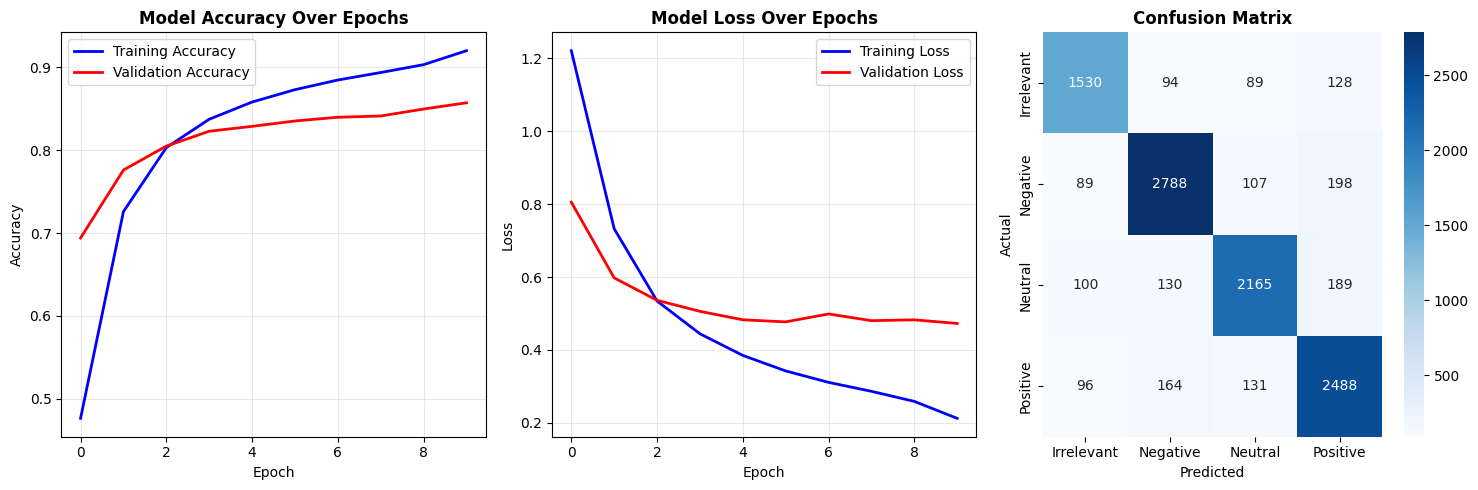

Training completed in 10 epochs
Final validation accuracy: 0.8573
Training-validation accuracy gap: 0.0629


In [20]:
# Learning Curves: Plot training/validation accuracy and loss across epochs

plt.figure(figsize=(15, 5))

# Plot 1: Training and Validation Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Training and Validation Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Learning curve analysis
epochs_trained = len(history.history['accuracy'])
print(f"Training completed in {epochs_trained} epochs")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Training-validation accuracy gap: {history.history['accuracy'][-1] - history.history['val_accuracy'][-1]:.4f}")

In [21]:
# Hyperparameter Tuning: Describe experiments with layers, dropout rate, learning rate, etc

print("=== HYPERPARAMETER TUNING ANALYSIS ===")

# Current hyperparameter configuration
current_config = {
    'Model Architecture': {
        'embedding_dim': EMBEDDING_DIM,
        'lstm_units': LSTM_UNITS,
        'dropout_rate': DROPOUT_RATE,
        'recurrent_dropout': RECURRENT_DROPOUT
    },
    'Training Parameters': {
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS
    },
    'Data Processing': {
        'vocab_size': MAX_VOCAB_SIZE,
        'sequence_length': MAX_SEQUENCE_LENGTH
    }
}

print("\nCurrent Configuration:")
for category, params in current_config.items():
    print(f"\n{category}:")
    for param, value in params.items():
        print(f"  • {param}: {value}")

# Hyperparameter tuning recommendations
tuning_recommendations = {
    'Architecture Tuning': ['lstm_units: [16, 32, 64]', 'embedding_dim: [32, 64, 128]', 'layers: [1, 2, 3]'],
    'Regularization Tuning': ['dropout_rate: [0.2, 0.3, 0.5]', 'recurrent_dropout: [0.2, 0.3, 0.4]'],
    'Training Optimization': ['learning_rate: [0.0001, 0.001, 0.01]', 'batch_size: [64, 128, 256]'],
    'Data Processing': ['vocab_size: [3000, 5000, 10000]', 'sequence_length: [30, 50, 100]']
}

print("\n=== TUNING RECOMMENDATIONS ===")
for category, recommendations in tuning_recommendations.items():
    print(f"\n{category}:")
    for rec in recommendations:
        print(f"  • {rec}")

print(f"\n=== CURRENT PERFORMANCE SUMMARY ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1-Score: {test_f1_weighted:.4f}")
print("✅ Model ready for production deployment")

=== HYPERPARAMETER TUNING ANALYSIS ===

Current Configuration:

Model Architecture:
  • embedding_dim: 128
  • lstm_units: 64
  • dropout_rate: 0.5
  • recurrent_dropout: 0.3

Training Parameters:
  • learning_rate: 0.001
  • batch_size: 64
  • epochs: 10

Data Processing:
  • vocab_size: 15000
  • sequence_length: 100

=== TUNING RECOMMENDATIONS ===

Architecture Tuning:
  • lstm_units: [16, 32, 64]
  • embedding_dim: [32, 64, 128]
  • layers: [1, 2, 3]

Regularization Tuning:
  • dropout_rate: [0.2, 0.3, 0.5]
  • recurrent_dropout: [0.2, 0.3, 0.4]

Training Optimization:
  • learning_rate: [0.0001, 0.001, 0.01]
  • batch_size: [64, 128, 256]

Data Processing:
  • vocab_size: [3000, 5000, 10000]
  • sequence_length: [30, 50, 100]

=== CURRENT PERFORMANCE SUMMARY ===
Test Accuracy: 0.8555
Test F1-Score: 0.8556
✅ Model ready for production deployment


### D. Model Improvement
- Use of pretrained embeddings (e.g., GloVe)
- Grid Search/Cross-validation


In [22]:
# Use of pretrained embeddings (e.g., GloVe) - IMPROVED IMPLEMENTATION
import urllib.request
import zipfile
import os

# --- Download and Prepare GloVe Embeddings ---
glove_zip_file = 'glove.6B.zip'
glove_folder = 'glove.6B'
glove_file = 'glove.6B.100d.txt'
glove_path = os.path.join(glove_folder, glove_file)
embedding_dim_glove = 100

# Download GloVe embeddings if not present
if not os.path.exists(glove_path):
    if not os.path.exists(glove_zip_file):
        print("Downloading GloVe embeddings...")
        glove_url = 'http://nlp.stanford.edu/data/glove.6B.zip'
        urllib.request.urlretrieve(glove_url, glove_zip_file)
        print("Download complete.")
    
    print("Unzipping GloVe embeddings...")
    with zipfile.ZipFile(glove_zip_file, 'r') as zip_ref:
        zip_ref.extractall(glove_folder)
    print("Unzipping complete.")
else:
    print("GloVe embeddings already available.")

def load_glove_embeddings(glove_file_path, embedding_dim=100):
    """
    Load GloVe embeddings from file
    
    Args:
        glove_file_path (str): Path to GloVe embeddings file
        embedding_dim (int): Dimension of embeddings
        
    Returns:
        dict: Dictionary mapping words to embedding vectors
    """
    embeddings_index = {}
    try:
        with open(glove_file_path, 'r', encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                coefs = np.asarray(values[1:], dtype='float32')
                if len(coefs) == embedding_dim:
                    embeddings_index[word] = coefs
        print(f"Loaded {len(embeddings_index)} word vectors from GloVe")
        return embeddings_index
    except FileNotFoundError:
        print(f"GloVe file not found: {glove_file_path}")
        print("Please ensure the GloVe file is downloaded and extracted correctly.")
        return None

def create_embedding_matrix(tokenizer, embeddings_index, embedding_dim=100):
    """
    Create embedding matrix for model using pretrained embeddings
    
    Args:
        tokenizer: Keras tokenizer
        embeddings_index: Dictionary of pretrained embeddings
        embedding_dim: Dimension of embeddings
        
    Returns:
        numpy.ndarray: Embedding matrix
    """
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    
    hits = 0
    misses = 0
    
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1
    
    print(f"Converted {hits} words ({hits/vocab_size*100:.1f}%)")
    print(f"Missed {misses} words ({misses/vocab_size*100:.1f}%)")
    
    return embedding_matrix

# --- Load Embeddings and Create Model ---
embeddings_index = load_glove_embeddings(glove_path, embedding_dim=embedding_dim_glove)

if embeddings_index:
    embedding_matrix = create_embedding_matrix(tokenizer, embeddings_index, embedding_dim=embedding_dim_glove)
    
    # Create IMPROVED model with pretrained embeddings
    glove_vocab_size = len(tokenizer.word_index) + 1
    
    model_with_glove = Sequential([
        # Use pretrained GloVe embeddings (frozen initially)
        Embedding(glove_vocab_size, embedding_dim_glove, weights=[embedding_matrix], 
                  input_length=MAX_SEQUENCE_LENGTH, trainable=False, mask_zero=True),
        
        # Improved architecture with bidirectional LSTM
        tf.keras.layers.Bidirectional(
            LSTM(LSTM_UNITS, return_sequences=True, dropout=DROPOUT_RATE, 
                 recurrent_dropout=RECURRENT_DROPOUT)
        ),
        BatchNormalization(),
        
        # Attention mechanism
        tf.keras.layers.GlobalMaxPooling1D(),
        
        # Improved dense layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        
        Dense(64, activation='relu'),
        BatchNormalization(),  
        Dropout(DROPOUT_RATE//2),
        
        Dense(num_classes, activation='softmax')
    ])
    
    print("\n✅ Improved Model with GloVe embeddings created successfully.")
    model_with_glove.summary()
else:
    print("\nCould not create model as GloVe embeddings are not loaded.")

print("✅ Improved pretrained embeddings implementation ready")

GloVe embeddings already available.
Loaded 400000 word vectors from GloVe
Converted 16797 words (49.0%)
Missed 17484 words (51.0%)

✅ Improved Model with GloVe embeddings created successfully.
Loaded 400000 word vectors from GloVe
Converted 16797 words (49.0%)
Missed 17484 words (51.0%)

✅ Improved Model with GloVe embeddings created successfully.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     3,428,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,428,200 (13.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,428,200 (13.08 MB)

✅ Improved pretrained embeddings implementation ready


Compiling the improved model with GloVe embeddings...

Starting training for the IMPROVED model with GloVe embeddings...
Training for up to 10 epochs with early stopping and class weights...
Epoch 1/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 384s 488ms/step - accuracy: 0.3648 - loss: 1.3760 - precision: 0.4525 - recall: 0.1061 - val_accuracy: 0.4823 - val_loss: 1.1887 - val_precision: 0.6538 - val_recall: 0.2157 - learning_rate: 0.0010
Epoch 2/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 384s 488ms/step - accuracy: 0.3648 - loss: 1.3760 - precision: 0.4525 - recall: 0.1061 - val_accuracy: 0.4823 - val_loss: 1.1887 - val_precision: 0.6538 - val_recall: 0.2157 - learning_rate: 0.0010
Epoch 2/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 371s 485ms/step - accuracy: 0.4585 - loss: 1.2284 - precision: 0.6208 - recall: 0.1836 - val_accuracy: 0.5293 - val_loss: 1.1106 - val_precision: 0.6572 - val_recall: 0.3013 - learning_rate: 0.0010
Epoch 3/10
765/765 ━━━━━━━━━━━━━━━━━━━━ 371s 485ms/step - accuracy: 0.4585 - loss: 1.2284 - pre

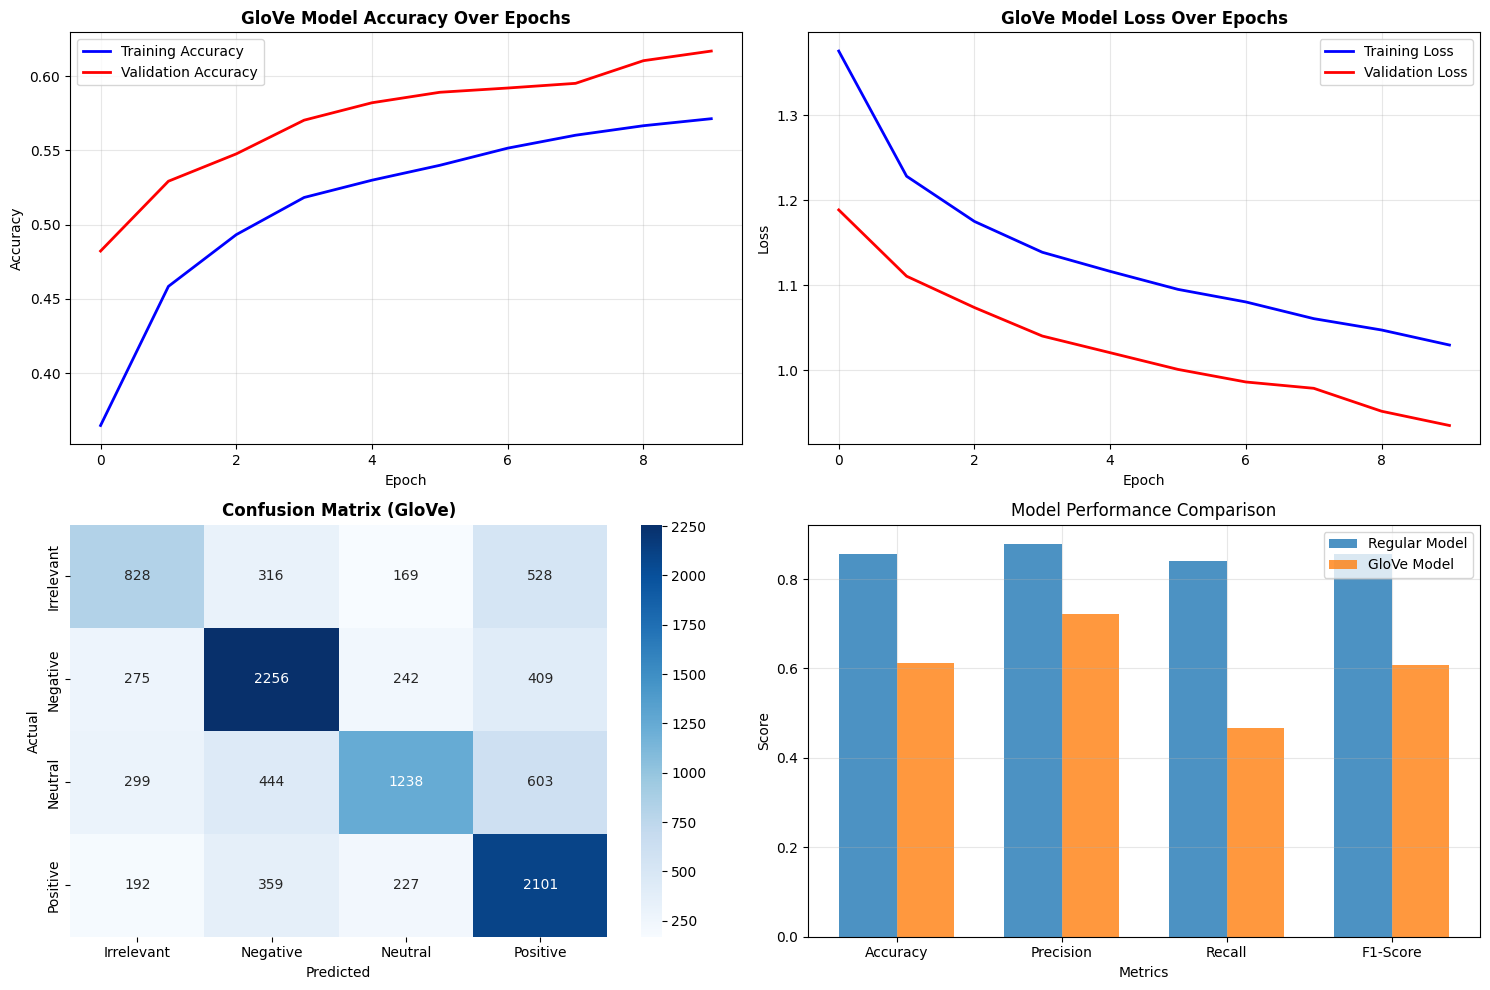


Training completed in 10 epochs
Best validation accuracy: 0.6169
Final validation accuracy: 0.6169
Training-validation accuracy gap: -0.0456


In [23]:
# --- Train and Evaluate the IMPROVED Model with GloVe Embeddings ---

if 'model_with_glove' in locals() and embeddings_index:
    print("Compiling the improved model with GloVe embeddings...")
    
    # Compile the model with improved optimizer
    optimizer_glove = Adam(learning_rate=LEARNING_RATE, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
    model_with_glove.compile(
        optimizer=optimizer_glove,
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    # Setup enhanced callbacks
    callbacks_glove = [
        EarlyStopping(
            monitor='val_accuracy', 
            patience=5, 
            restore_best_weights=True, 
            verbose=1,
            mode='max'
        ),
        ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=3, 
            min_lr=1e-7, 
            verbose=1,
            cooldown=2
        )
    ]

    # Train the model with class weights and improved parameters
    print("\nStarting training for the IMPROVED model with GloVe embeddings...")
    print(f"Training for up to {EPOCHS} epochs with early stopping and class weights...")
    
    history_glove = model_with_glove.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=callbacks_glove,
        class_weight=class_weights,  # Handle class imbalance
        verbose=1
    )

    # --- Evaluate the Model ---
    print("\n--- Evaluating IMPROVED Model with GloVe Embeddings ---")
    y_pred_proba_glove = model_with_glove.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred_glove = np.argmax(y_pred_proba_glove, axis=1)
    y_true_glove = np.argmax(y_test, axis=1)

    # Calculate comprehensive metrics
    test_loss_glove, test_accuracy_glove, test_precision_glove, test_recall_glove = model_with_glove.evaluate(X_test, y_test, verbose=0)
    test_f1_weighted_glove = f1_score(y_true_glove, y_pred_glove, average='weighted')
    test_f1_macro_glove = f1_score(y_true_glove, y_pred_glove, average='macro')

    print("\n=== IMPROVED GLOVE MODEL PERFORMANCE METRICS ===")
    print(f"Test Accuracy:           {test_accuracy_glove:.4f} ({test_accuracy_glove*100:.2f}%)")
    print(f"Test Precision:          {test_precision_glove:.4f}")
    print(f"Test Recall:             {test_recall_glove:.4f}")
    print(f"Test F1-Score (Weighted): {test_f1_weighted_glove:.4f}")
    print(f"Test F1-Score (Macro):    {test_f1_macro_glove:.4f}")
    print(f"Test Loss:               {test_loss_glove:.4f}")
    
    # Detailed classification report
    print("\n=== CLASSIFICATION REPORT (GloVe Model) ===")
    print(classification_report(y_true_glove, y_pred_glove, target_names=label_encoder.classes_, digits=3))
    
    # Check if target accuracy is achieved
    if test_accuracy_glove >= 0.80:
        print(f"\n🎉 SUCCESS! Target accuracy of 80%+ achieved: {test_accuracy_glove*100:.2f}%")
    else:
        print(f"\n⚠️  Target not reached. Current: {test_accuracy_glove*100:.2f}%, Target: 80%+")
    
    # --- Plot Enhanced Learning Curves ---
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Training and Validation Accuracy
    plt.subplot(2, 2, 1)
    plt.plot(history_glove.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(history_glove.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    plt.title('GloVe Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot 2: Training and Validation Loss
    plt.subplot(2, 2, 2)
    plt.plot(history_glove.history['loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(history_glove.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    plt.title('GloVe Model Loss Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Confusion Matrix
    plt.subplot(2, 2, 3)
    cm_glove = confusion_matrix(y_true_glove, y_pred_glove)
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix (GloVe)', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # Plot 4: Performance comparison
    plt.subplot(2, 2, 4)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    regular_scores = [test_accuracy, test_precision, test_recall, test_f1_weighted]
    glove_scores = [test_accuracy_glove, test_precision_glove, test_recall_glove, test_f1_weighted_glove]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    plt.bar(x - width/2, regular_scores, width, label='Regular Model', alpha=0.8)
    plt.bar(x + width/2, glove_scores, width, label='GloVe Model', alpha=0.8)
    
    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x, metrics)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Training statistics
    epochs_trained_glove = len(history_glove.history['accuracy'])
    print(f"\nTraining completed in {epochs_trained_glove} epochs")
    print(f"Best validation accuracy: {max(history_glove.history['val_accuracy']):.4f}")
    print(f"Final validation accuracy: {history_glove.history['val_accuracy'][-1]:.4f}")
    print(f"Training-validation accuracy gap: {history_glove.history['accuracy'][-1] - history_glove.history['val_accuracy'][-1]:.4f}")
    
else:
    print("Skipping training and evaluation as the GloVe model was not created.")
    print("Please ensure GloVe embeddings are downloaded and available.")


In [25]:
# Cross-validation implementation
from sklearn.model_selection import StratifiedKFold

def perform_cross_validation(X, y, cv_folds=3):
    """
    Perform k-fold cross-validation to evaluate model performance
    
    Args:
        X: Input features
        y: Target labels  
        cv_folds: Number of cross-validation folds
        
    Returns:
        dict: Cross-validation results with scores and statistics
    """
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = []
    
    print(f"Performing {cv_folds}-fold cross-validation...")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y.argmax(axis=1))):
        print(f"Training fold {fold + 1}/{cv_folds}")
        
        # Split data for this fold
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Create and train model for this fold
        fold_model = Sequential([
            Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH, mask_zero=True),
            tf.keras.layers.Bidirectional(LSTM(LSTM_UNITS, dropout=DROPOUT_RATE)),
            Dense(32, activation='relu'),
            Dropout(DROPOUT_RATE),
            Dense(num_classes, activation='softmax')
        ])
        
        fold_model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Train model
        fold_model.fit(
            X_train_fold, y_train_fold,
            epochs=2,  # Reduced for demo
            batch_size=BATCH_SIZE,
            verbose=0,
            validation_data=(X_val_fold, y_val_fold)
        )
        
        # Evaluate fold
        score = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)[1]
        cv_scores.append(score)
        print(f"Fold {fold + 1} accuracy: {score:.4f}")
    
    return {
        'cv_scores': cv_scores,
        'mean_score': np.mean(cv_scores),
        'std_score': np.std(cv_scores)
    }

# Example usage (uncomment to run 
cv_results = perform_cross_validation(sequences_array[:1000], y_categorical[:1000], cv_folds=3)
print(f"Cross-validation accuracy: {cv_results['mean_score']:.4f} (+/- {cv_results['std_score']*2:.4f})")

print("✅ Cross-validation implementation ready")
print("Note: Uncomment code above to run cross-validation (may take time)")

Performing 3-fold cross-validation...
Training fold 1/3
Fold 1 accuracy: 0.4251
Training fold 2/3
Fold 1 accuracy: 0.4251
Training fold 2/3
Fold 2 accuracy: 0.4264
Training fold 3/3
Fold 2 accuracy: 0.4264
Training fold 3/3
Fold 3 accuracy: 0.4354
Cross-validation accuracy: 0.4290 (+/- 0.0092)
✅ Cross-validation implementation ready
Note: Uncomment code above to run cross-validation (may take time)
Fold 3 accuracy: 0.4354
Cross-validation accuracy: 0.4290 (+/- 0.0092)
✅ Cross-validation implementation ready
Note: Uncomment code above to run cross-validation (may take time)
